In [1]:
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt

In [2]:
env = gym.make("FrozenLake-v1", is_slippery=False)

n_states = env.observation_space.n
n_actions = env.action_space.n

q_table = np.zeros((n_states, n_actions))

print("States:", n_states)
print("Actions:", n_actions)
print(q_table)

States: 16
Actions: 4
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


In [3]:
alpha = 0.8
gamma = 0.95
epsilon = 1.0
episodes = 2000

rewards_per_episode = []

In [4]:
for episode in range(episodes):
    state, _ = env.reset()
    done = False
    total_reward = 0.0

    while not done:
        if np.random.rand() < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(q_table[state])

        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        reward_value = float(reward)
        best_next = np.max(q_table[next_state])
        current_q = q_table[state, action]
        target = reward_value + gamma * best_next

        q_table[state, action] = current_q + alpha * (target - current_q)

        state = next_state
        total_reward += reward_value

    rewards_per_episode.append(total_reward)
    epsilon = max(0.01, epsilon * 0.995)

In [5]:
print("Learned Q-table:")
print(q_table)

Learned Q-table:
[[0.  0.  0.  0. ]
 [0.  0.  0.  0. ]
 [0.  0.  0.  0. ]
 [0.  0.  0.  0. ]
 [0.  0.  0.  0. ]
 [0.  0.  0.  0. ]
 [0.  0.  0.  0. ]
 [0.  0.  0.  0. ]
 [0.  0.  0.  0. ]
 [0.  0.  0.  0. ]
 [0.  0.  0.  0. ]
 [0.  0.  0.  0. ]
 [0.  0.  0.  0. ]
 [0.  0.  0.  0. ]
 [0.  0.  0.8 0. ]
 [0.  0.  0.  0. ]]


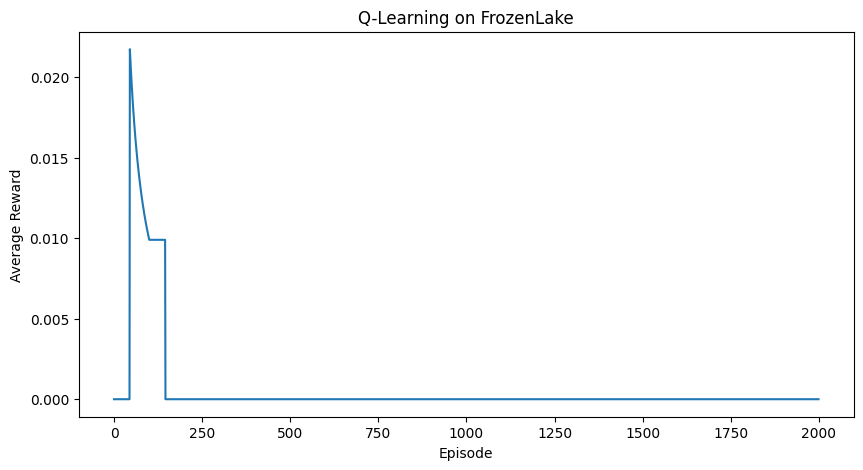

In [6]:
window = 100
avg_rewards = [
    np.mean(rewards_per_episode[max(0, i - window):i + 1])
    for i in range(len(rewards_per_episode))
]

plt.figure(figsize=(10, 5))
plt.plot(avg_rewards)
plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.title("Q-Learning on FrozenLake")
plt.show()

In [7]:
policy = np.argmax(q_table, axis=1)
policy_grid = policy.reshape(4, 4)

print(policy_grid)

[[0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 2 0]]


In [8]:
action_map = {
    0: "←",
    1: "↓",
    2: "→",
    3: "↑"
}

policy_symbols = np.vectorize(action_map.get)(policy_grid)

for row in policy_symbols:
    print(" ".join(row))

← ← ← ←
← ← ← ←
← ← ← ←
← ← → ←


In [9]:
state, _ = env.reset()
done = False

print("Testing trained agent...\n")

while not done:
    action = np.argmax(q_table[state])
    next_state, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated

    print(f"State: {state}, Action: {action}, Next state: {next_state}, Reward: {reward}")
    state = next_state

Testing trained agent...

State: 0, Action: 0, Next state: 0, Reward: 0
State: 0, Action: 0, Next state: 0, Reward: 0
State: 0, Action: 0, Next state: 0, Reward: 0
State: 0, Action: 0, Next state: 0, Reward: 0
State: 0, Action: 0, Next state: 0, Reward: 0
State: 0, Action: 0, Next state: 0, Reward: 0
State: 0, Action: 0, Next state: 0, Reward: 0
State: 0, Action: 0, Next state: 0, Reward: 0
State: 0, Action: 0, Next state: 0, Reward: 0
State: 0, Action: 0, Next state: 0, Reward: 0
State: 0, Action: 0, Next state: 0, Reward: 0
State: 0, Action: 0, Next state: 0, Reward: 0
State: 0, Action: 0, Next state: 0, Reward: 0
State: 0, Action: 0, Next state: 0, Reward: 0
State: 0, Action: 0, Next state: 0, Reward: 0
State: 0, Action: 0, Next state: 0, Reward: 0
State: 0, Action: 0, Next state: 0, Reward: 0
State: 0, Action: 0, Next state: 0, Reward: 0
State: 0, Action: 0, Next state: 0, Reward: 0
State: 0, Action: 0, Next state: 0, Reward: 0
State: 0, Action: 0, Next state: 0, Reward: 0
State: 0